PLOTANDO UMA SÉRIE TEMPORAL - Índice de Vendas no Setor Varejista Brasileiro

<Axes: title={'center': 'Índice de volume de vendas no setor varejista brasileiro'}, xlabel='Data', ylabel='Índice'>

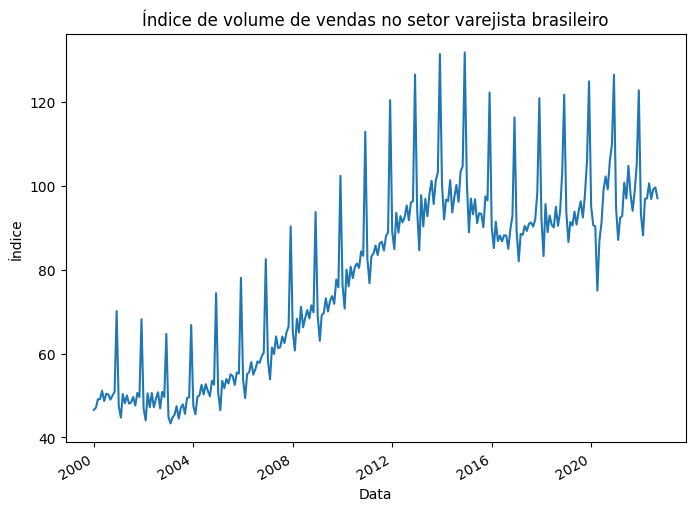

In [2]:
import pandas as pd
import numpy as np

# Carregando o dataset do Índice de Volume de Vendas no Setor Varejista Brasileiro
dataset = pd.read_csv('retail_index_br.csv', delimiter=';', index_col='date', parse_dates=True)

# Transformando os dados de y em float
dataset['retail_index'].astype(float)

# Plotando a Time Series
dataset['retail_index'].plot(figsize=(8, 6),
title='Índice de volume de vendas no setor varejista brasileiro',
xlabel='Data', ylabel='Índice', x_compat=True)

PREVISÃO COM HOLT-WINTERS

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<Axes: xlabel='date'>

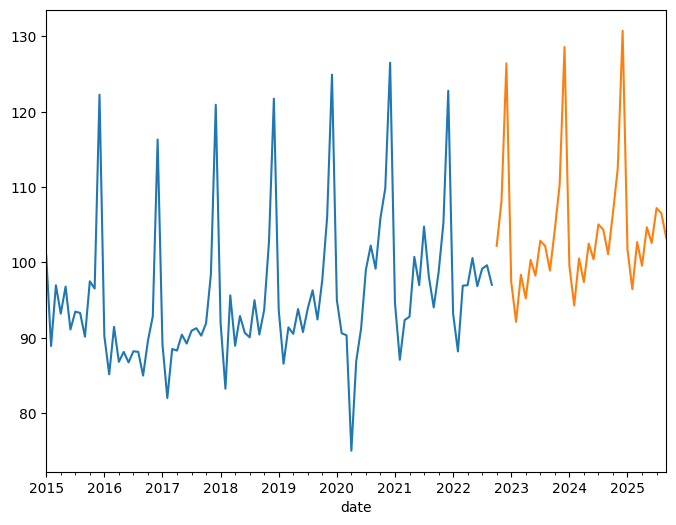

In [3]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# importando o dataset
df = pd.read_csv('retail_index_br.csv', delimiter=';', index_col='date', parse_dates=True)

# criando um modelo de previsão
model = ExponentialSmoothing(endog=df.retail_index, trend = 'add',
                             seasonal = 'add', seasonal_periods=12).fit()

# realizando a previsão
# limitando o gráfico para facilitar a visualização
# prevendo 3 anos
predictions = model.forecast(steps = 36)
df['retail_index']['2015-01-01':].plot(figsize= (8, 6))
predictions.plot()


PREVISÃO COM ARIMA

In [4]:
# Setando uma versão do NumPy que o pmdarima funcione
!pip install numpy==1.23.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 57.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have numpy 1.23.5 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatible.
chex 0.1.89 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
scikit-image 0.25.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
pymc 5.22.0 requires numpy>=1.25.0, but you have numpy 1.23.5 which is incompatible.
bigframes 2.4.0 requires numpy>=1.24.0, but you have numpy 1.23.5 which is incompatible.
albucore 0.0.24 requires numpy>=1.24.4, but you have numpy 1.23.

In [1]:
# No Google Colab, resolvendo conflitos inicialmente para executar o pmdarima
!pip install statsmodels
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.7 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

 ARIMA(1,1,1)(0,1,1)[12]          


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: xlabel='date'>

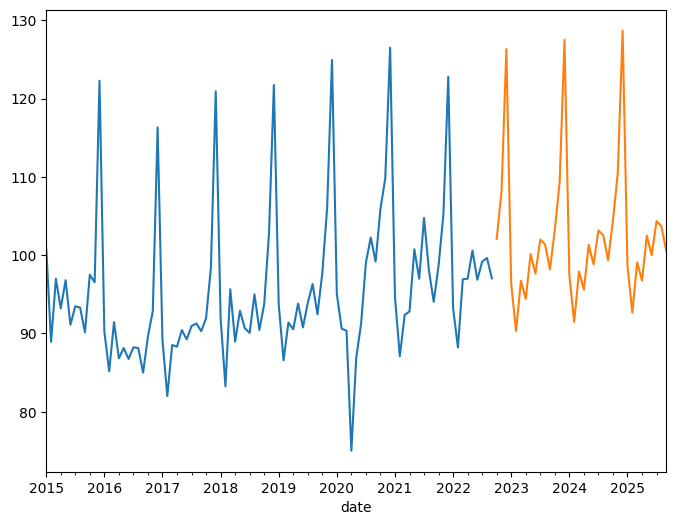

In [2]:
import pandas as pd
from pmdarima import auto_arima

# importando o dataset
df = pd.read_csv('retail_index_br.csv', delimiter=';', index_col='date', parse_dates=True)

# criando um modelo de previsão
# o parâmetro m indica a sazonalidade, que neste dataset acontece anualmente
model = auto_arima(y = df['retail_index'], m = 12)
# mostrando os melhores parâmetros calculados pelo auto_arima
print(model)

# realizando a previsão
predictions = pd.Series(model.predict(n_periods = 36))
df['retail_index']['2015-01-01':].plot(figsize= (8, 6))
predictions.plot()

CALCULANDO O MAPE DOS MODELOS BASEADOS EM HOLT-WINTERS E ARIMA - SEPARANDO DADOS PARA TREINO E TESTE

In [3]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# importando o dataset
df = pd.read_csv('retail_index_br.csv', delimiter=';', index_col='date', parse_dates=True)

# no total, o dataset retail_index_br possui 273 meses (De jan 2000 a set 2022)
# 218 serão usados para treinamento e 55 para testes
meses_teste = 55
conjunto_treinamento = df.iloc[:-meses_teste, :]
conjunto_teste = df.iloc[-meses_teste:, :]

print(conjunto_teste)
print(conjunto_treinamento)

            retail_index
date                    
2018-03-01         95.64
2018-04-01         88.95
2018-05-01         92.90
2018-06-01         90.66
2018-07-01         90.07
2018-08-01         95.00
2018-09-01         90.44
2018-10-01         93.74
2018-11-01        102.88
2018-12-01        121.74
2019-01-01         93.69
2019-02-01         86.57
2019-03-01         91.39
2019-04-01         90.53
2019-05-01         93.82
2019-06-01         90.77
2019-07-01         93.91
2019-08-01         96.31
2019-09-01         92.44
2019-10-01         97.72
2019-11-01        106.08
2019-12-01        124.93
2020-01-01         95.02
2020-02-01         90.61
2020-03-01         90.34
2020-04-01         75.02
2020-05-01         86.90
2020-06-01         91.21
2020-07-01         99.06
2020-08-01        102.25
2020-09-01         99.18
2020-10-01        105.89
2020-11-01        109.85
2020-12-01        126.51
2021-01-01         94.64
2021-02-01         87.09
2021-03-01         92.36
2021-04-01         92.81


PREVISÃO DOS DADOS DE TESTE COM HOLT-WINTERS

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<Axes: xlabel='date'>

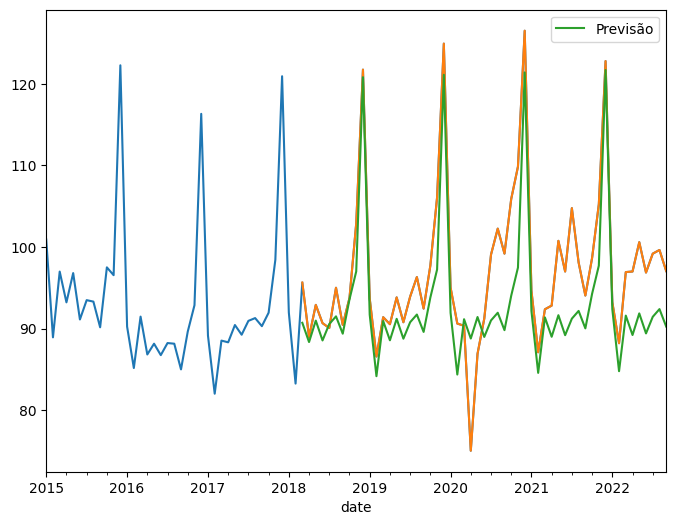

In [4]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# aplicando o modelo com dados de treinamento
model = ExponentialSmoothing(endog=conjunto_treinamento.retail_index, trend = 'mul',
                             seasonal = 'mul', seasonal_periods=12).fit()

# realizando a previsão no mesmo tamanho dos dados de teste
forecasting_hw = model.forecast(steps = len(conjunto_teste))

# mostrando dados de treinamento
df['retail_index']['2015-01-01':].plot(figsize= (8, 6))

# mostrando dados de teste
conjunto_teste['retail_index'][:].plot()

# mostrando previsões
forecasting_hw.plot(legend = True, label='Previsão')

PREVISÃO DOS DADOS DE TESTE COM ARIMA

In [5]:
from pmdarima.arima import auto_arima

# aplicando o modelo com dados de treinamento
model = auto_arima(y = conjunto_treinamento['retail_index'], m = 12)

# mostrando o resultado do melhor modelo ARIMA detectado
print(model)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

 ARIMA(1,1,3)(0,1,2)[12]          


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: xlabel='date'>

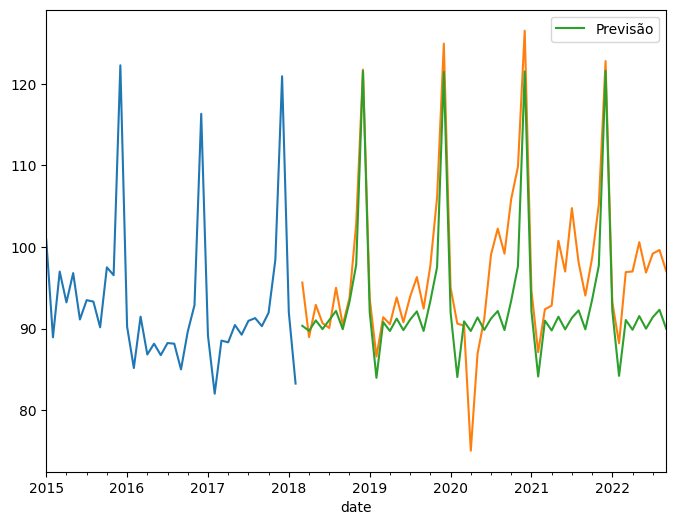

In [7]:
# realizando as previsoes
forecasting_arima = pd.Series(model.predict(n_periods=len(conjunto_teste)))

# mostrando dados de treinamento
conjunto_treinamento['retail_index']['2015-01-01':].plot(figsize= (8, 6))

# mostrando dados de teste
conjunto_teste['retail_index'][:].plot()

# mostrando previsões
forecasting_arima.plot(legend = True, label='Previsão')

REALIZANDO O CÁLCULO DOS MAPEs

In [8]:
import numpy as np

# Função do MAPE
def MAPE(y_true, y_pred):
  y_true, y_pred = np.array(y_true), np.array(y_pred)
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Cálculo dos MAPEs
print('MAPE Holt-Winters:', MAPE(conjunto_teste['retail_index'], forecasting_hw))
print('MAPE ARIMA:', MAPE(conjunto_teste['retail_index'], forecasting_arima))

MAPE Holt-Winters: 4.966410167855559
MAPE ARIMA: 4.87668824477438
